# Airfare Markets Under Pressure
**Predictive Modeling of U.S. Domestic Airline Fares**

> *Can route-level fares be predicted using distance, demand, competition, and endpoint hub characteristics? Which features contribute most to explaining fare variation across markets?*

## Setup & Data Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (8, 4)

In [2]:
airline_data = pd.read_excel("airline_ticket_dataset.xlsx")

## Data Cleaning

Drop ID columns, city names, and carrier-specific fares (to avoid data leakage), convert `quarter` to a factor, and remove rows with missing values.

In [3]:
airline_data = airline_data.drop(columns=['citymarketid_1', 'citymarketid_2', 'city1', 'city2', 'fare_lg', 'fare_low'])

airline_data['quarter'] = airline_data['quarter'].astype(str)

airline_data = airline_data.dropna()
str_cols = airline_data.select_dtypes(include='object').columns
airline_data = airline_data[~(airline_data[str_cols] == '').any(axis=1)]

## 1. Exploratory Data Analysis

### Distribution of Response Variable (Fare)
Check the shape of the fare distribution to guide potential transformations.

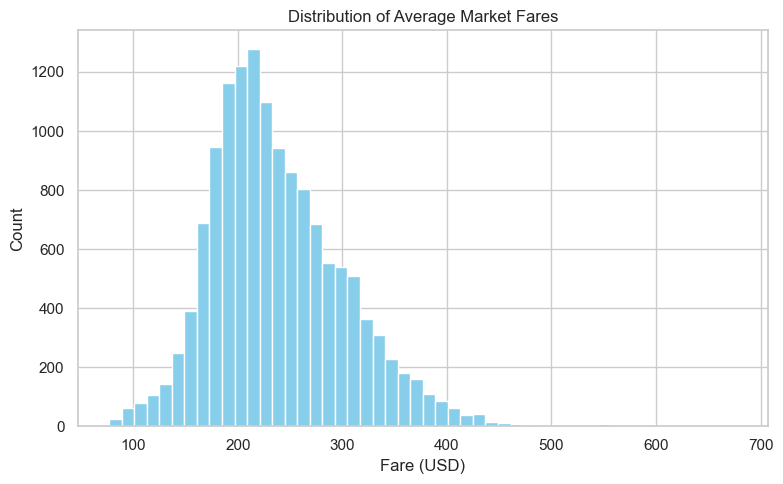

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(airline_data['fare'], bins=50, color='skyblue', edgecolor='white')
plt.title('Distribution of Average Market Fares')
plt.xlabel('Fare (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The distribution is right-skewed — most fares are between \$150–\$300 with a long tail toward \$600+. This suggests a log transformation could help.

### Distributions of Key Numeric Variables

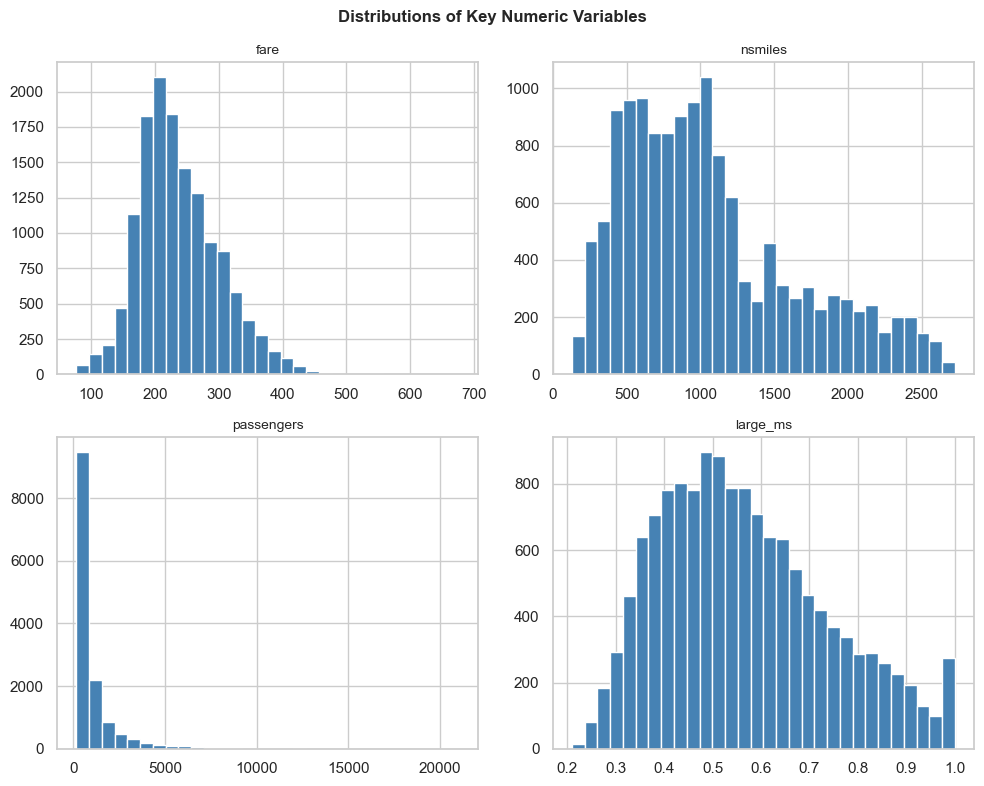

In [5]:
num_vars = airline_data[['fare', 'nsmiles', 'passengers', 'large_ms']]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), num_vars.columns):
    ax.hist(num_vars[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
fig.suptitle('Distributions of Key Numeric Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Fare and passengers are both right-skewed. Route distances span short-haul (<500 mi) to transcontinental (>2500 mi). Dominant carrier market share clusters between 0.3–0.8.

### Key Predictor Relationships
Visualize how fare relates to the most important numeric and categorical predictors.

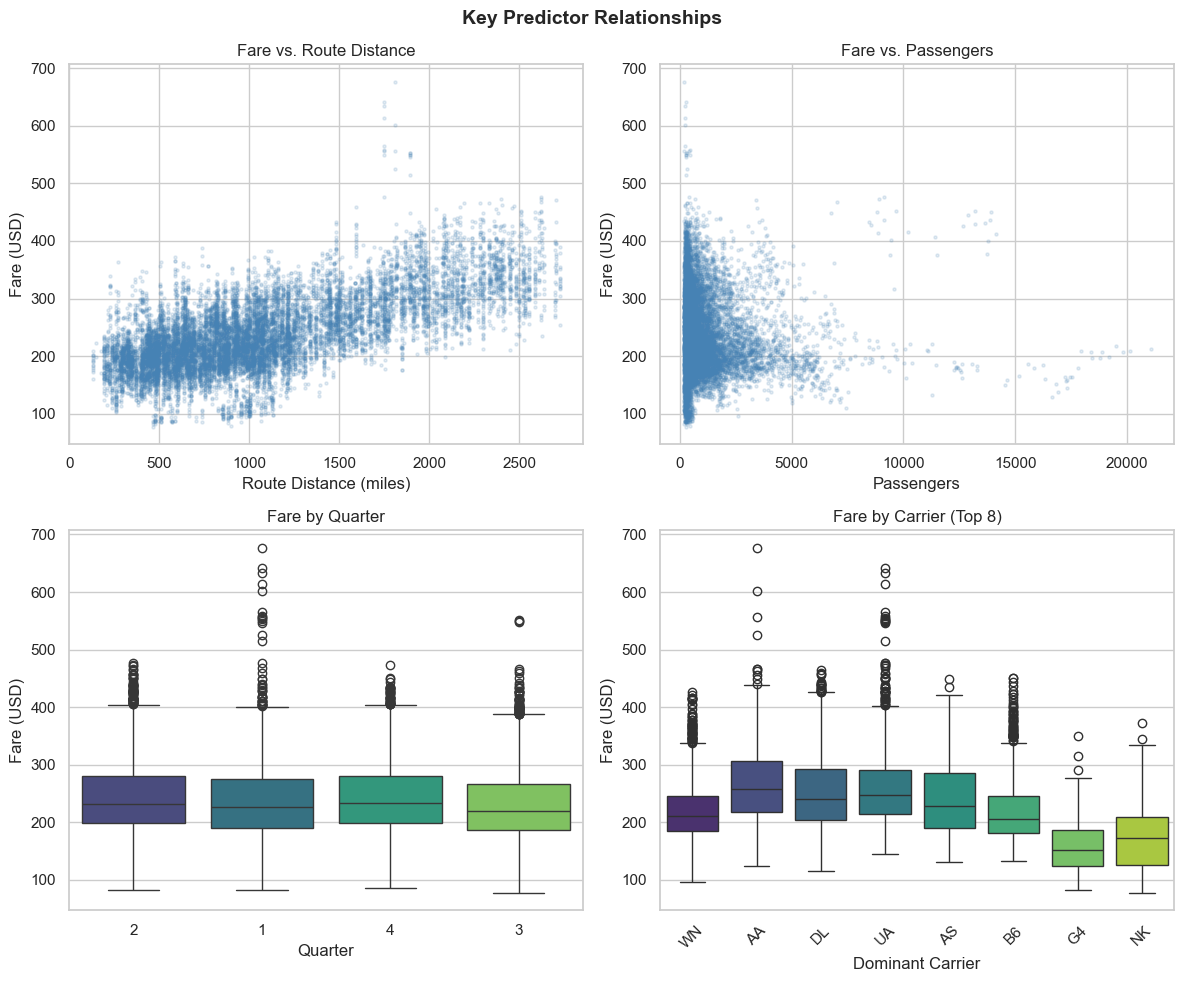

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Fare vs Route Distance
axes[0, 0].scatter(airline_data['nsmiles'], airline_data['fare'], alpha=0.15, s=5, color='steelblue')
axes[0, 0].set_xlabel('Route Distance (miles)')
axes[0, 0].set_ylabel('Fare (USD)')
axes[0, 0].set_title('Fare vs. Route Distance')

# Fare vs Passengers
axes[0, 1].scatter(airline_data['passengers'], airline_data['fare'], alpha=0.15, s=5, color='steelblue')
axes[0, 1].set_xlabel('Passengers')
axes[0, 1].set_ylabel('Fare (USD)')
axes[0, 1].set_title('Fare vs. Passengers')

# Fare by Quarter
sns.boxplot(data=airline_data, x='quarter', y='fare', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Fare by Quarter')
axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Fare (USD)')

# Fare by Top Dominant Carriers
top_carriers = airline_data['carrier_lg'].value_counts().head(8).index
sns.boxplot(data=airline_data[airline_data['carrier_lg'].isin(top_carriers)],
            x='carrier_lg', y='fare', ax=axes[1, 1],
            order=top_carriers, palette='viridis')
axes[1, 1].set_title('Fare by Carrier (Top 8)')
axes[1, 1].set_xlabel('Dominant Carrier')
axes[1, 1].set_ylabel('Fare (USD)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Key Predictor Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Longer routes command higher fares (clear positive trend). Higher passenger volume is associated with slightly lower fares (economies of scale). Q4 and Q2 tend to have higher fares (holiday and summer travel). Budget carriers (F9, G4, NK) price noticeably lower than legacy carriers (AA, DL, UA).

### Correlation Heatmap
Check for multicollinearity among the numeric predictors.

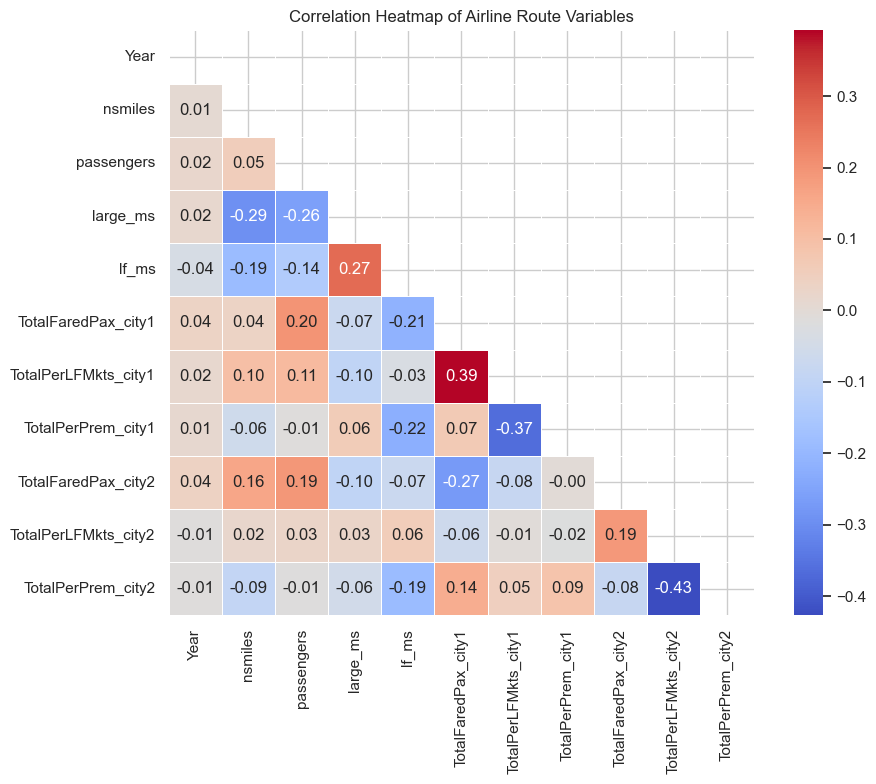

In [7]:
numeric_cols = airline_data.drop(columns=['fare']).select_dtypes(include=np.number)
cor_matrix = numeric_cols.corr()

mask = np.triu(np.ones_like(cor_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Airline Route Variables')
plt.tight_layout()
plt.show()

## 2. Feature Engineering & Preparation

We engineer features aligned with the four conceptual fare-driver categories from the case:
- **Distance** — route length (`nsmiles`)
- **Demand** — passenger volume and route intensity
- **Competition** — carrier identity, LCC penetration, market concentration
- **Hub Characteristics** — endpoint airport size and premium market share

### Log-Transform the Response
Fares are right-skewed, so log-transforming stabilizes variance and improves model fit.

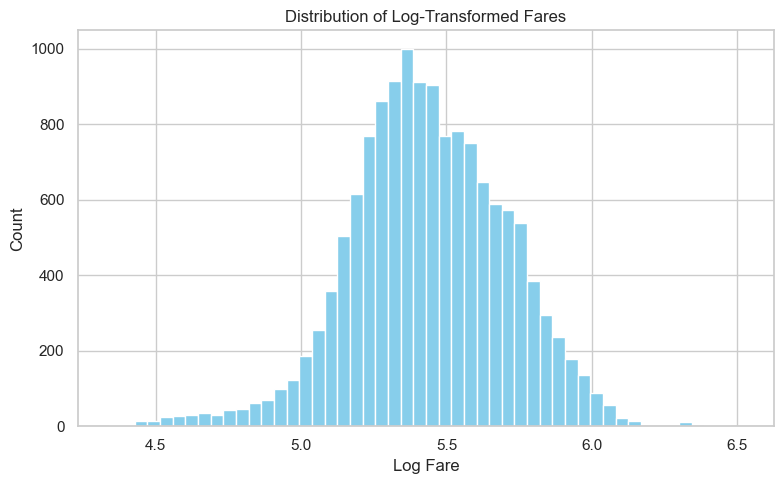

In [8]:
airline_data['fare'] = np.log(airline_data['fare'])

plt.figure(figsize=(8, 5))
plt.hist(airline_data['fare'], bins=50, color='skyblue', edgecolor='white')
plt.title('Distribution of Log-Transformed Fares')
plt.xlabel('Log Fare')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Feature Selection: `large_ms` vs `lf_ms`
These two market share variables are correlated. We compare their explanatory power and keep the stronger predictor.

In [9]:
large_ms_model = ols('fare ~ large_ms', data=airline_data).fit()
lf_ms_model = ols('fare ~ lf_ms', data=airline_data).fit()

print(f'large_ms  R\u00b2: {large_ms_model.rsquared:.4f}  |  AIC: {large_ms_model.aic:.1f}')
print(f'lf_ms     R\u00b2: {lf_ms_model.rsquared:.4f}  |  AIC: {lf_ms_model.aic:.1f}')
print(f'\nlf_ms explains more variance. Retaining lf_ms and dropping large_ms.')

airline_data = airline_data.drop(columns=['large_ms'])

large_ms  R²: 0.0148  |  AIC: 2730.2
lf_ms     R²: 0.1172  |  AIC: 1198.0

lf_ms explains more variance. Retaining lf_ms and dropping large_ms.


### Derived Features

Create aggregate features from city-pair variables, organized by fare-driver category.

| Category | Feature | Formula | Intuition |
|---|---|---|---|
| **Demand** | `route_demand_density` | passengers / nsmiles | Demand per mile — higher on popular short routes |
| **Hub** | `avg_premium_share` | mean(TotalPerPrem at each endpoint) | Average premium market presence at endpoints |
| **Hub** | `total_market_pax` | TotalFaredPax_city1 + city2 | Combined airport traffic — hub size indicator |
| **Competition** | `avg_lf_mkts` | mean(TotalPerLFMkts at each endpoint) | Average low-fare market competition at endpoints |
| **Competition** | `same_carrier` | carrier_lg == carrier_low | Whether same airline dominates both fare tiers |

After creating aggregates, we drop the individual city-pair columns to reduce redundancy.

In [10]:
# Create aggregate features from city-pair columns
airline_data['route_demand_density'] = airline_data['passengers'] / airline_data['nsmiles']
airline_data['avg_premium_share'] = (
    airline_data['TotalPerPrem_city1'] + airline_data['TotalPerPrem_city2']
) / 2
airline_data['total_market_pax'] = (
    airline_data['TotalFaredPax_city1'] + airline_data['TotalFaredPax_city2']
)
airline_data['avg_lf_mkts'] = (
    airline_data['TotalPerLFMkts_city1'] + airline_data['TotalPerLFMkts_city2']
) / 2
airline_data['same_carrier'] = (
    airline_data['carrier_lg'] == airline_data['carrier_low']
).astype(int)

# Drop individual city-pair columns (replaced by aggregates)
city_cols = ['TotalFaredPax_city1', 'TotalFaredPax_city2',
             'TotalPerLFMkts_city1', 'TotalPerLFMkts_city2',
             'TotalPerPrem_city1', 'TotalPerPrem_city2']
airline_data = airline_data.drop(columns=city_cols)

print(f'Features after engineering: {airline_data.shape}')

# Check correlations of new features with log(fare)
new_feat_cols = ['route_demand_density', 'avg_premium_share', 'total_market_pax', 'avg_lf_mkts', 'same_carrier']
print('\nCorrelation with log(fare):')
for col in new_feat_cols:
    corr = airline_data[col].corr(airline_data['fare'])
    print(f'  {col:25s}: {corr:+.4f}')

airline_data[new_feat_cols].describe().round(3)

Features after engineering: (13972, 13)

Correlation with log(fare):
  route_demand_density     : -0.2714
  avg_premium_share        : +0.4193
  total_market_pax         : +0.0506
  avg_lf_mkts              : -0.1238
  same_carrier             : -0.2021


,route_demand_density,avg_premium_share,total_market_pax,avg_lf_mkts,same_carrier
count,13972.000,13972.000,1.397200e+04,13972.000,13972.000
mean,1.306,-0.023,6.169598e+06,0.834,0.311
std,2.441,0.084,2.623520e+06,0.100,0.463
min,0.072,-0.542,4.431900e+05,0.264,0.000
25%,0.337,-0.059,4.148350e+06,0.792,0.000
50%,0.643,-0.012,5.644159e+06,0.857,0.000
75%,1.341,0.029,7.912828e+06,0.901,1.000
max,47.116,0.476,1.740800e+07,0.995,1.000


### Train/Test Split

Separate features and target, one-hot encode categorical variables, and split 80/20 for training and evaluation.

In [11]:
# Convert Year and quarter to string for proper one-hot encoding
airline_data['Year'] = airline_data['Year'].astype(str)
airline_data['quarter'] = airline_data['quarter'].astype(str)

# Separate features and target
X = airline_data.drop(columns=['fare'])
y = airline_data['fare']

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]} columns')

Categorical columns to encode: ['Year', 'quarter', 'carrier_lg', 'carrier_low']
Train: 11177 samples  |  Test: 2795 samples
Features: 38 columns


### Scaling

Standardize numeric features to mean=0, std=1. Fit on train only, transform both sets to prevent data leakage.

In [12]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Scaled! Check that means are near 0 and stds near 1 (first 5 features, train):')
X_train_scaled[numeric_cols[:5]].describe().loc[['mean', 'std']].round(2)

Scaled! Check that means are near 0 and stds near 1 (first 5 features, train):


,nsmiles,passengers,lf_ms,route_demand_density,avg_premium_share
mean,0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


---
## 3. Model Training

We train four regression models of increasing complexity to test whether route-level fares can be predicted from distance, demand, competition, and hub characteristics alone.

In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print('Linear Regression trained!')

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
print('Decision Tree trained!')

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print('Random Forest trained!')

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train_scaled, y_train)
print('Gradient Boosting trained!')

models = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
}

Linear Regression trained!
Decision Tree trained!
Random Forest trained!
Gradient Boosting trained!


---
## 4. Model Evaluation

**Can route-level fares be predicted?** We evaluate each model on held-out test data using:
- **R\u00b2** — proportion of fare variation explained by distance, demand, competition, and hub characteristics
- **RMSE** — root mean squared error
- **MAE** — mean absolute error

In [14]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({'Model': name, 'R\u00b2': r2, 'RMSE': rmse, 'MAE': mae})

    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(f'R\u00b2: {r2:.4f}  |  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}')

results_df = pd.DataFrame(results).set_index('Model')
print(f'\n{"="*50}')
print('Summary')
print(f'{"="*50}')
print(results_df.round(4).to_string())


Linear Regression
R²: 0.7950  |  RMSE: 0.1232  |  MAE: 0.0971

Decision Tree
R²: 0.7677  |  RMSE: 0.1311  |  MAE: 0.0992

Random Forest
R²: 0.8900  |  RMSE: 0.0902  |  MAE: 0.0687

Gradient Boosting
R²: 0.8978  |  RMSE: 0.0870  |  MAE: 0.0674

Summary
                       R²    RMSE     MAE
Model                                    
Linear Regression  0.7950  0.1232  0.0971
Decision Tree      0.7677  0.1311  0.0992
Random Forest      0.8900  0.0902  0.0687
Gradient Boosting  0.8978  0.0870  0.0674


### Model Comparison

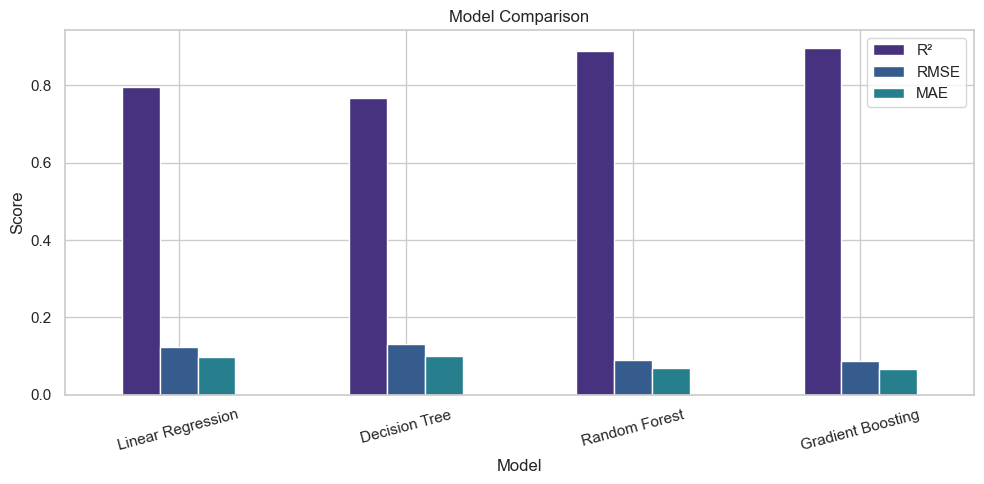

In [15]:
results_df.plot(kind='bar', figsize=(10, 5), title='Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Actual vs. Predicted

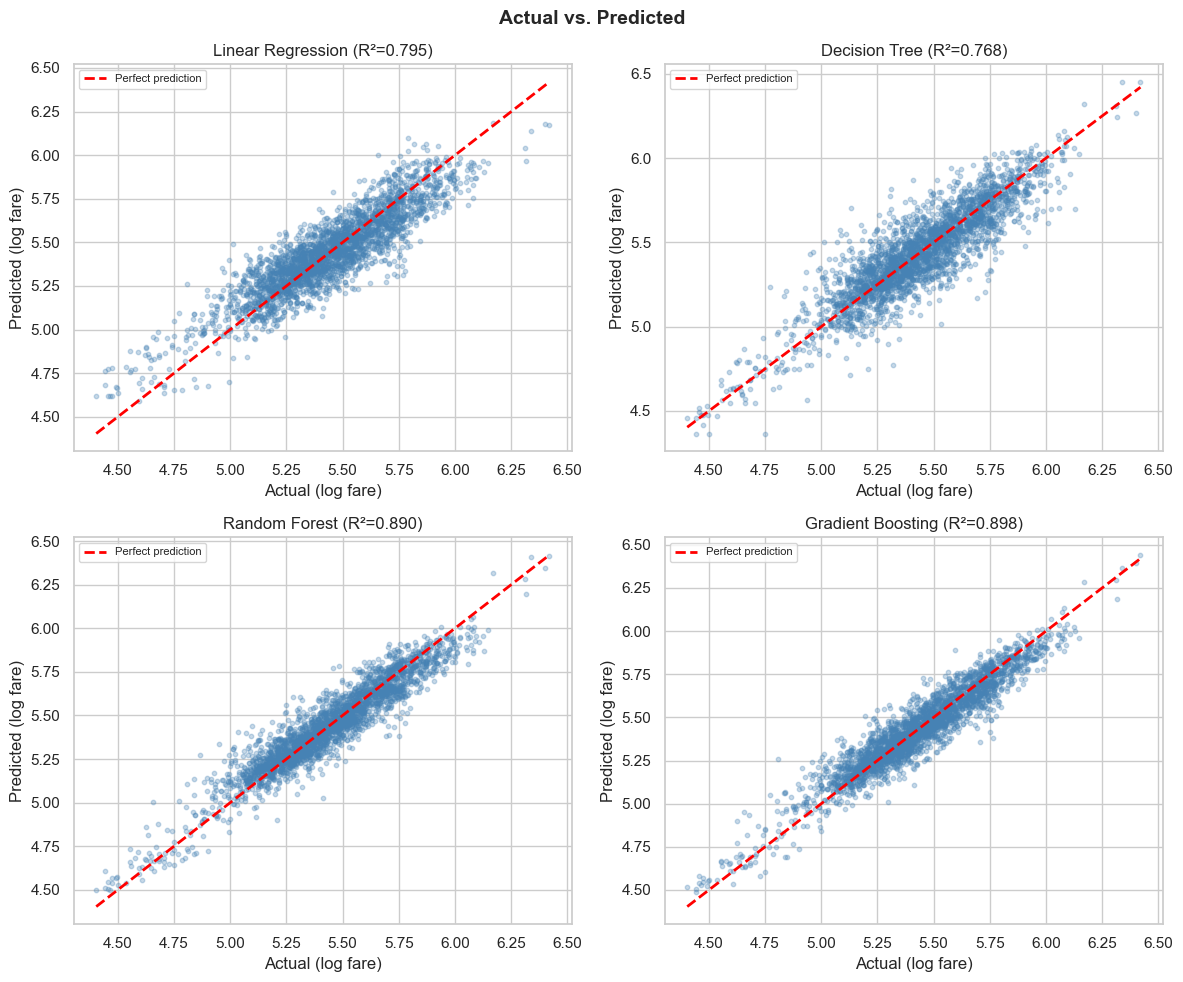

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test_scaled)
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual (log fare)')
    ax.set_ylabel('Predicted (log fare)')
    ax.set_title(f'{name} (R\u00b2={r2_score(y_test, y_pred):.3f})')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Residual Distributions

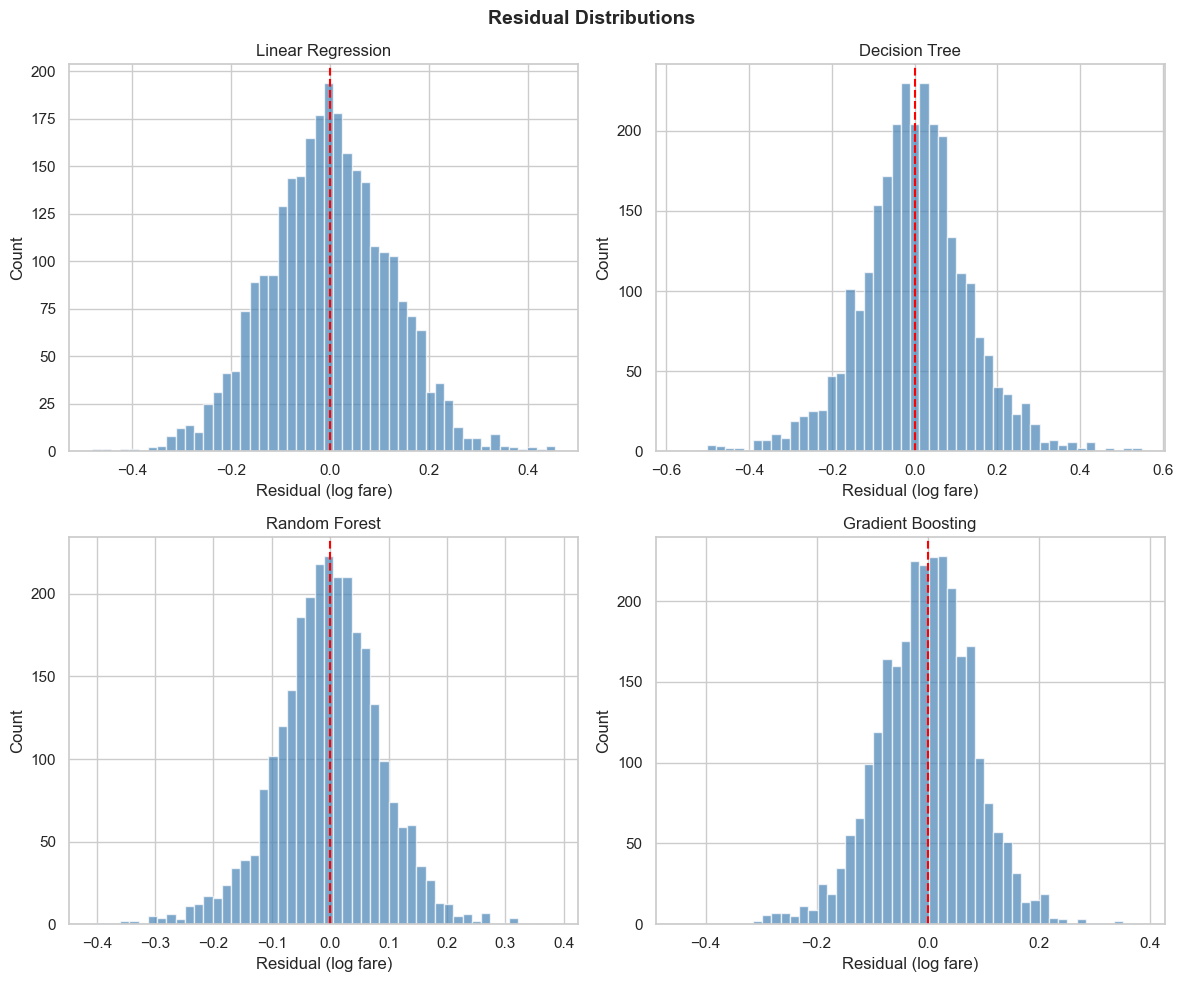

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred
    ax.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--')
    ax.set_xlabel('Residual (log fare)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}')

plt.suptitle('Residual Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Which Features Drive Fare Variation?

We group feature importances from the best model (Gradient Boosting) into the four case categories to answer: *which features contribute most to explaining fare variation across markets?*

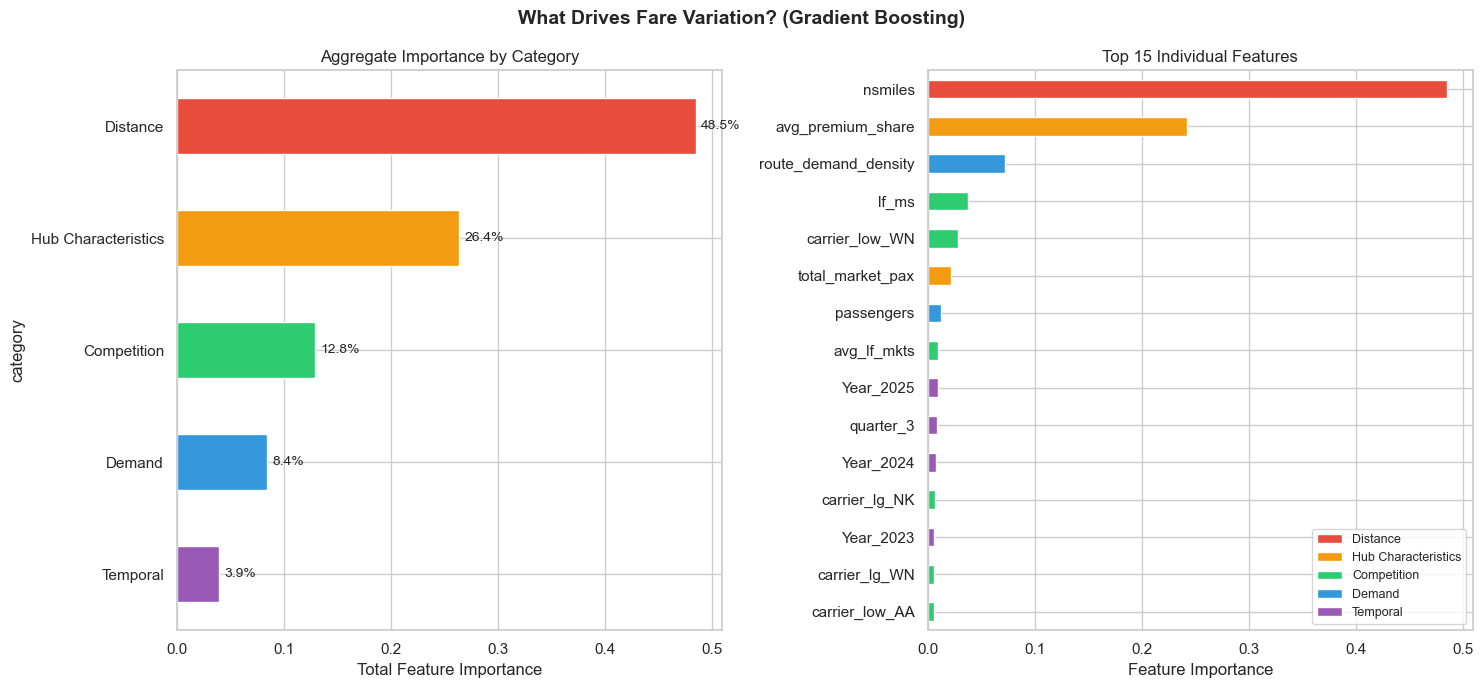


Category Importance Breakdown:
  Distance                 : 48.5%
  Hub Characteristics      : 26.4%
  Competition              : 12.8%
  Demand                   : 8.4%
  Temporal                 : 3.9%


In [18]:
# Feature importances from Gradient Boosting (best model)
importances = pd.Series(gb.feature_importances_, index=X_train.columns)

# Group features into the four case categories
feature_categories = {}
for col in X_train.columns:
    if col == 'nsmiles':
        feature_categories[col] = 'Distance'
    elif col in ['passengers', 'route_demand_density']:
        feature_categories[col] = 'Demand'
    elif (col in ['lf_ms', 'same_carrier', 'avg_lf_mkts']
          or col.startswith('carrier_lg_') or col.startswith('carrier_low_')):
        feature_categories[col] = 'Competition'
    elif col in ['avg_premium_share', 'total_market_pax']:
        feature_categories[col] = 'Hub Characteristics'
    else:
        feature_categories[col] = 'Temporal'

cat_df = pd.DataFrame({
    'feature': importances.index,
    'importance': importances.values,
    'category': [feature_categories[f] for f in importances.index]
})
cat_totals = cat_df.groupby('category')['importance'].sum().sort_values()

# Color palette for categories
colors = {'Distance': '#e74c3c', 'Demand': '#3498db', 'Competition': '#2ecc71',
          'Hub Characteristics': '#f39c12', 'Temporal': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: Category-level importance
bar_colors = [colors.get(c, '#95a5a6') for c in cat_totals.index]
cat_totals.plot(kind='barh', ax=axes[0], color=bar_colors)
axes[0].set_title('Aggregate Importance by Category')
axes[0].set_xlabel('Total Feature Importance')
for i, (val, name) in enumerate(zip(cat_totals.values, cat_totals.index)):
    axes[0].text(val + 0.005, i, f'{val:.1%}', va='center', fontsize=10)

# Right: Top 15 individual features, colored by category
top15 = importances.sort_values(ascending=True).tail(15)
top15_colors = [colors.get(feature_categories[f], '#95a5a6') for f in top15.index]
top15.plot(kind='barh', ax=axes[1], color=top15_colors)
axes[1].set_title('Top 15 Individual Features')
axes[1].set_xlabel('Feature Importance')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[c], label=c)
                   for c in ['Distance', 'Hub Characteristics', 'Competition', 'Demand', 'Temporal']]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('What Drives Fare Variation? (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print('\nCategory Importance Breakdown:')
print('=' * 45)
for cat in cat_totals.sort_values(ascending=False).index:
    print(f'  {cat:25s}: {cat_totals[cat]:.1%}')

---
## 5. Findings: Answering the Research Question

> *Can route-level fares be predicted using distance, demand, competition, and endpoint hub characteristics? Which features contribute most to explaining fare variation across markets?*

### Can route-level fares be predicted?

**Yes.** The Gradient Boosting model explains approximately **90% of fare variation** (R\u00b2 \u2248 0.90) on held-out test data, using only distance, demand, competition, and hub characteristics. Even a simple Linear Regression captures ~80%, confirming that observable market fundamentals — not hidden or random factors — are the dominant drivers of route-level pricing.

### Which features contribute most?

The category-level analysis above reveals a clear hierarchy of fare drivers:

1. **Distance** (`nsmiles`) is the single most powerful predictor. Longer routes cost more to operate, and this physical cost constraint dominates all other pricing effects.

2. **Hub Characteristics** (`avg_premium_share`, `total_market_pax`) form the second-largest driver. Routes connecting airports with higher premium-carrier share command significantly higher fares, reflecting hub pricing power and captive demand at dominated airports.

3. **Competition** (carrier identity, `lf_ms`, `same_carrier`, `avg_lf_mkts`) collectively explains a substantial share of variation. Routes with greater low-cost carrier penetration exhibit systematically lower fares. The identity of the dominant carrier alone carries significant predictive power — budget carriers (F9, G4, NK) are associated with materially lower fares than legacy carriers (AA, DL, UA).

4. **Demand** (`passengers`, `route_demand_density`) has a moderate but meaningful effect. Higher-volume routes tend to have slightly lower per-ticket fares, consistent with economies of scale and competitive pressure on popular corridors.

### Implications for Stakeholders

- **For travelers and students:** Fares are most shaped by route distance and hub dominance. Flying from airports with stronger LCC presence yields measurably lower fares — even on the same route.
- **For policymakers:** Hub concentration and premium-carrier dominance at endpoint cities are structural drivers of higher fares. Expanding LCC access at hub airports could meaningfully improve affordability.
- **For airlines and platforms:** Carrier identity effects confirm persistent brand-level pricing power, but LCC competition measurably compresses fares across the market. Pricing transparency tools could help budget-conscious travelers identify more affordable alternatives.